# Exercises 3 – Car ownership

In [ ]:
# Imports and dataset load (placed at top so cells can run standalone)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Full logistic regression: predict 1 vs 2 cars using the exact variables you requested
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
# Reload fresh data to avoid state issues
df_model = pd.read_excel('bilejerskab2026.xlsx')
# Filter to households with exactly 1 or 2 cars and create binary target Car2 (1 if two cars)
df_model = df_model[df_model['Car'].isin([1,2])].copy()
df_model['Car2'] = (df_model['Car'] == 2).astype(int)
# Create HHLicenses dummies as requested (HHLicense 1 is reference)
if 'HHLicenses' in df_model.columns:
    df_model['HHLicenses_2'] = (df_model['HHLicenses'] == 2).astype(int)
    df_model['HHLicenses_3plus'] = (df_model['HHLicenses'] >= 3).astype(int)
else:
    df_model['HHLicenses_2'] = 0
    df_model['HHLicenses_3plus'] = 0
# Create Female dummy if missing
if 'Female' not in df_model.columns and 'Gender' in df_model.columns:
    df_model['Female'] = (df_model['Gender'] == 2).astype(int)
# AgeGroup dummies
agegroup_map = {2: '8_14', 3: '15_18', 4: '19_24', 5: '25_29', 6: '30_54', 7: '55_64', 8: '65_74', 9: '75_84'}
if 'AgeGroup_Label' not in df_model.columns and 'AgeGroup' in df_model.columns:
    df_model['AgeGroup_Label'] = df_model['AgeGroup'].map(agegroup_map).astype(str)
age_dummies = pd.get_dummies(df_model['AgeGroup_Label'], prefix='AgeG')
for c in ['AgeG_19_24', 'AgeG_25_29', 'AgeG_55_64', 'AgeG_65_74', 'AgeG_75_84', 'AgeG_30_54']:
    if c not in age_dummies.columns:
        age_dummies[c] = 0
df_model = pd.concat([df_model, age_dummies], axis=1)
# LMA dummies
lma_map = {1: 'Fuldtid', 2: 'Deltid', 3: 'Elev_Stud', 4: 'Pens', 5: 'Arbsog', 6: 'Uden_Arb'}
if 'LMA_Label' not in df_model.columns and 'LMA' in df_model.columns:
    df_model['LMA_Label'] = df_model['LMA'].map(lma_map).astype(str)
lma_dummies = pd.get_dummies(df_model['LMA_Label'], prefix='LMA')
for c in ['LMA_Arbsog', 'LMA_Deltid', 'LMA_Elev_Stud', 'LMA_Pens', 'LMA_Uden_Arb', 'LMA_Fuldtid']:
    if c not in lma_dummies.columns:
        lma_dummies[c] = 0
df_model = pd.concat([df_model, lma_dummies], axis=1)
# Drop temporary labels if present
for lbl in ['AgeGroup_Label', 'LMA_Label']:
    if lbl in df_model.columns:
        df_model = df_model.drop(columns=[lbl])
# Build RHS exactly as requested (reference categories excluded by omission)
rhs = [
    'AgeG_19_24', 'AgeG_25_29', 'AgeG_55_64', 'AgeG_65_74', 'AgeG_75_84',
    'LMA_Arbsog', 'LMA_Deltid', 'LMA_Elev_Stud', 'LMA_Pens', 'LMA_Uden_Arb',
    'HHIncome', 'Female', 'HHLicenses_2', 'HHLicenses_3plus', 'Children', 'Year'
]
# Fill any missing RHS columns with zeros to avoid singular errors from absent dummies
for v in rhs:
    if v not in df_model.columns:
        df_model[v] = 0
# Fit logit model predicting probability of 2 cars (Car2)
formula = 'Car2 ~ ' + ' + '.join(rhs)
print('Formula:', formula)
model = smf.logit(formula, data=df_model).fit(disp=0)
print(model.summary())
# Odds ratios
ci = model.conf_int()
or_df = pd.DataFrame({
    'OR': np.exp(model.params),
    '2.5%': np.exp(ci[0]),
    '97.5%': np.exp(ci[1])
})
display(or_df)
# Add text labels inside the bars (percentage values)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=9, weight='bold', color='white')

ax.set_title('Markedsandel for 0, 1 og 2 biler', fontsize=16)
ax.set_xlabel('Antal biler', fontsize=14)
ax.set_ylabel('Markedsandel (%)', fontsize=14)
ax.set_xticklabels([str(int(x)) for x in plot_df.index], rotation=0)
if plot_df.shape[1] > 1:
    ax.legend(title='År')
else:
    ax.get_legend().remove()
ax.set_ylim(0, max(plot_df.max().max(), 1) + 10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Loaded 7853 rows from bilejerskab2026.xlsx
Columns: ['ID', 'HHLicenses', 'Gender', 'Children', 'Year', 'AgeGroup', 'LMA', 'Car', 'HHIncome', 'PerIncome']


/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [7]:
# Kort tabel over antal (N) for hver 0, 1 og 2 biler
# Sørg for at øverste data-indlæsningscelle er kørt først
if 'df_bilejerskab' not in globals():
    raise RuntimeError('df_bilejerskab ikke fundet - kør øverste dataindlæsningscelle først')
counts = df_bilejerskab['Car'].value_counts().reindex([0,1,2], fill_value=0)
result = counts.to_frame(name='N')
display(result)

,N
Car,
0,618
1,5082
2,2153


<br>

## b) Describe how the number of cars relates to number of driver’s licenses, income and number of kids, e.g. using cross tabulation, group averages or correlations. Comment on the results.

In [8]:
# b) Relation between number of cars and licenses, income, and children

# 1) cars_driver_license: average number of cars for HHLicenses = 1,2,3,4,5
cars_driver_license = (
    df_bilejerskab[df_bilejerskab['HHLicenses'].isin([1, 2, 3, 4, 5])]
    .groupby('HHLicenses', as_index=False)
    .agg(
        AvgCars=('Car', 'mean'),
        N=('Car', 'size')
    )
    .sort_values('HHLicenses')
)
cars_driver_license['AvgCars'] = cars_driver_license['AvgCars'].round(3)

# 2) cars_income: average number of cars by HHIncome intervals (quantile-based bins)
income_bins = pd.qcut(df_bilejerskab['HHIncome'], q=5, duplicates='drop')
cars_income = (
    df_bilejerskab.assign(HHIncomeInterval=income_bins)
    .groupby('HHIncomeInterval', as_index=False, observed=False)
    .agg(
        AvgCars=('Car', 'mean'),
        N=('Car', 'size')
    )
    .sort_values('HHIncomeInterval')
)
cars_income['AvgCars'] = cars_income['AvgCars'].round(3)

# 3) cars_kids: average number of cars for Children = 0,1,2,3,4,5,6
cars_kids = (
    df_bilejerskab[df_bilejerskab['Children'].isin([0, 1, 2, 3, 4, 5, 6])]
    .groupby('Children', as_index=False)
    .agg(
        AvgCars=('Car', 'mean'),
        N=('Car', 'size')
    )
    .sort_values('Children')
)
cars_kids['AvgCars'] = cars_kids['AvgCars'].round(3)

print('cars_driver_license')
display(cars_driver_license)

print('cars_income')
display(cars_income)

print('cars_kids')
display(cars_kids)

cars_driver_license


,HHLicenses,AvgCars,N
0,1,0.819,1167
1,2,1.269,5973
2,3,1.484,490
3,4,1.521,73
4,5,1.250,4


cars_income


,HHIncomeInterval,AvgCars,N
0,"(-0.001, 349.0]",0.848,1577
1,"(349.0, 525.8]",1.116,1564
2,"(525.8, 657.0]",1.262,1592
3,"(657.0, 811.0]",1.318,1567
4,"(811.0, 10558.0]",1.435,1553


cars_kids


,Children,AvgCars,N
0,0,1.121,4629
1,1,1.250,1186
2,2,1.309,1506
3,3,1.396,470
4,4,1.440,50
5,5,1.500,10
6,6,0.500,2


**Kommentar til resultater (b)**
- **Driver's licenses:** Gennemsnitligt antal biler stiger fra ca. 0.82 (1 licens) til ca. 1.52 (4 licenser). Kategorien med 5 licenser har meget få observationer (N=4), så den er usikker.
- **Indkomst:** Der er en tydelig positiv sammenhaeng mellem indkomst og antal biler. AvgCars stiger gradvist fra ca. 0.85 i laveste interval til ca. 1.44 i hoejeste interval.
- **Boern:** AvgCars stiger overordnet med antal boern (fra ca. 1.12 ved 0 boern til ca. 1.50 ved 5 boern). Kategorien med 6 boern har kun N=2 og boer tolkes med stor forsigtighed.

In [9]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# 1) Cross tabulations (row percentages) with N
crosstab_license = pd.crosstab(
    df_bilejerskab["HHLicenses"],
    df_bilejerskab["Car"],
    normalize="index"
).round(3)
crosstab_license["N"] = df_bilejerskab.groupby("HHLicenses").size()

crosstab_kids = pd.crosstab(
    df_bilejerskab["Children"],
    df_bilejerskab["Car"],
    normalize="index"
).round(3)
crosstab_kids["N"] = df_bilejerskab.groupby("Children").size()

# Crosstab for income with fixed intervals + N
income_bins = [0, 300, 500, 700, 900, 1200, np.inf]
income_labels = [
    "0-300",
    "301-500",
    "501-700",
    "701-900",
    "901-1200",
    "1200+"
]
income_intervals_for_crosstab = pd.cut(
    df_bilejerskab["HHIncome"],
    bins=income_bins,
    labels=income_labels,
    include_lowest=True
    )
crosstab_income = pd.crosstab(
    income_intervals_for_crosstab,
    df_bilejerskab["Car"],
    normalize="index"
).round(3)
crosstab_income["N"] = income_intervals_for_crosstab.value_counts().reindex(crosstab_income.index).astype(int)

# 3) Spearman correlations
corr_rows = []
for x in ["HHLicenses", "HHIncome", "Children"]:
    rho, pval = spearmanr(df_bilejerskab["Car"], df_bilejerskab[x], nan_policy="omit")
    corr_rows.append({"Variable": x, "SpearmanRho": round(rho, 3), "PValue": pval})

correlation_table = pd.DataFrame(corr_rows)

print("Cross tab: Car vs HHLicenses (row shares + N)")
display(crosstab_license)

print("Cross tab: Car vs Children (row shares + N)")
display(crosstab_kids)

print("Cross tab: Car vs HHIncome interval (fixed intervals, row shares + N)")
display(crosstab_income)

print("Spearman correlations with Car")
display(correlation_table)

Cross tab: Car vs HHLicenses (row shares + N)


Car,0,1,2,N
HHLicenses,,,,
0,0.952,0.048,0.000,146
1,0.215,0.751,0.034,1167
2,0.038,0.655,0.307,5973
3,0.004,0.508,0.488,490
4,0.014,0.452,0.534,73
5,0.000,0.750,0.250,4


Cross tab: Car vs Children (row shares + N)


Car,0,1,2,N
Children,,,,
0,0.103,0.672,0.225,4629
1,0.060,0.631,0.309,1186
2,0.037,0.617,0.346,1506
3,0.023,0.557,0.419,470
4,0.020,0.520,0.460,50
5,0.000,0.500,0.500,10
6,0.500,0.500,0.000,2


Cross tab: Car vs HHIncome interval (fixed intervals, row shares + N)


Car,0,1,2,N
HHIncome,,,,
0-300,0.248,0.691,0.061,1198
301-500,0.103,0.733,0.165,1579
501-700,0.040,0.664,0.296,2437
701-900,0.024,0.602,0.374,1576
901-1200,0.025,0.525,0.451,728
1200+,0.015,0.445,0.540,335


Spearman correlations with Car


,Variable,SpearmanRho,PValue
0,HHLicenses,0.365,1.978236e-245
1,HHIncome,0.352,1.479155e-227
2,Children,0.166,1.318896e-49


<br>

## c) Estimate a logistic regression, where you model whether a family has a car or not. 
Includeas many variables as possible to explain behaviour and consider non-linear effects. Comment
on the estimated parameters and argue for your choice of final model.

Dummier for aldersgrupper

In [10]:
# Create dummy columns for AgeGroup
if 'df_bilejerskab' not in globals():
    import pandas as pd
    df_bilejerskab = pd.read_excel('bilejerskab2026.xlsx')

agegroup_map = {
    2: '8-14',
    3: '15-18',
    4: '19-24',
    5: '25-29',
    6: '30-54',
    7: '55-64',
    8: '65-74',
    9: '75-84'
}

df_bilejerskab['AgeGroupLabel'] = df_bilejerskab['AgeGroup'].map(agegroup_map)

agegroup_dummies = pd.get_dummies(df_bilejerskab['AgeGroupLabel'], prefix='AgeGroup')
df_bilejerskab = pd.concat([df_bilejerskab, agegroup_dummies], axis=1)

df_bilejerskab[['AgeGroup', 'AgeGroupLabel'] + list(agegroup_dummies.columns)].head()

,AgeGroup,AgeGroupLabel,AgeGroup_15-18,AgeGroup_19-24,AgeGroup_25-29,AgeGroup_30-54,AgeGroup_55-64,AgeGroup_65-74,AgeGroup_75-84,AgeGroup_8-14
0,7,55-64,False,False,False,False,True,False,False,False
1,6,30-54,False,False,False,True,False,False,False,False
2,7,55-64,False,False,False,False,True,False,False,False
3,6,30-54,False,False,False,True,False,False,False,False
4,7,55-64,False,False,False,False,True,False,False,False


In [11]:
# Age group distribution
if 'df_bilejerskab' not in globals():
    import pandas as pd
    df_bilejerskab = pd.read_excel('bilejerskab2026.xlsx')

# Ensure the AgeGroupLabel column exists
if 'AgeGroupLabel' not in df_bilejerskab.columns:
    agegroup_map = {
        2: '8-14',
        3: '15-18',
        4: '19-24',
        5: '25-29',
        6: '30-54',
        7: '55-64',
        8: '65-74',
        9: '75-84'
    }
    df_bilejerskab['AgeGroupLabel'] = df_bilejerskab['AgeGroup'].map(agegroup_map)

# Create age group distribution
age_dist = (
    df_bilejerskab['AgeGroupLabel']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'AgeGroupLabel': 'Count'})
)
age_dist.columns = ['AgeGroup', 'Count']
age_dist['Percentage'] = (age_dist['Count'] / age_dist['Count'].sum() * 100).round(2)

print("=" * 60)
print("AGE GROUP DISTRIBUTION")
print("=" * 60)
display(age_dist)
print(f"\nTotal observations: {age_dist['Count'].sum()}")

AGE GROUP DISTRIBUTION


,AgeGroup,Count,Percentage
0,15-18,45,0.57
1,19-24,281,3.58
2,25-29,457,5.82
3,30-54,4372,55.67
4,55-64,1588,20.22
5,65-74,861,10.96
6,75-84,242,3.08
7,8-14,7,0.09



Total observations: 7853


In [12]:
# Cross table for aldersgrupper og antal biler
import pandas as pd

if 'df_bilejerskab' not in globals():
    df_bilejerskab = pd.read_excel('bilejerskab2026.xlsx')

# Ensure the age group label exists
if 'AgeGroupLabel' not in df_bilejerskab.columns:
    agegroup_map = {
        2: '8-14',
        3: '15-18',
        4: '19-24',
        5: '25-29',
        6: '30-54',
        7: '55-64',
        8: '65-74',
        9: '75-84'
    }
    df_bilejerskab['AgeGroupLabel'] = df_bilejerskab['AgeGroup'].map(agegroup_map)

age_order = ['8-14', '15-18', '19-24', '25-29', '30-54', '55-64', '65-74', '75-84']

# Absolute counts
crosstab_age_car = pd.crosstab(
    df_bilejerskab['AgeGroupLabel'],
    df_bilejerskab['Car'],
    margins=True
).reindex(age_order + ['All'])

# Row percentages for easier interpretation, with N as the last column
crosstab_age_car_pct = pd.crosstab(
    df_bilejerskab['AgeGroupLabel'],
    df_bilejerskab['Car'],
    normalize='index'
).reindex(age_order).round(3) * 100
crosstab_age_car_pct['N'] = crosstab_age_car.loc[age_order, [0, 1, 2]].fillna(0).sum(axis=1).astype(int)
crosstab_age_car_pct = crosstab_age_car_pct[[col for col in crosstab_age_car_pct.columns if col != 'N'] + ['N']]

print('Krydstabel: aldersgrupper vs. antal biler')
display(crosstab_age_car.fillna(0).astype(int))

print('Rækkeprocenter (%)')
display(crosstab_age_car_pct)


Krydstabel: aldersgrupper vs. antal biler


Car,0,1,2,All
AgeGroupLabel,,,,
8-14,1,6,0,7
15-18,5,23,17,45
19-24,133,116,32,281
25-29,106,257,94,457
30-54,221,2665,1486,4372
55-64,59,1123,406,1588
65-74,57,695,109,861
75-84,36,197,9,242
All,618,5082,2153,7853


Rækkeprocenter (%)


Car,0,1,2,N
AgeGroupLabel,,,,
8-14,14.3,85.7,0.0,7
15-18,11.1,51.1,37.8,45
19-24,47.3,41.3,11.4,281
25-29,23.2,56.2,20.6,457
30-54,5.1,61.0,34.0,4372
55-64,3.7,70.7,25.6,1588
65-74,6.6,80.7,12.7,861
75-84,14.9,81.4,3.7,242


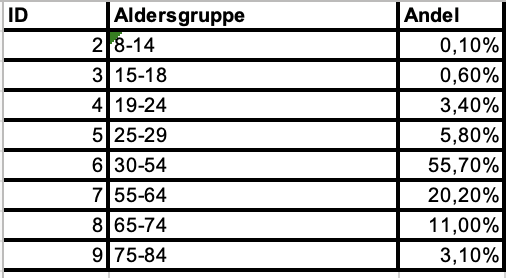

Dummies for om de har en bil

In [13]:
# Binary target for logistic regression: 1 if the family has at least one car, otherwise 0
if 'df_bilejerskab' not in globals():
    import pandas as pd
    df_bilejerskab = pd.read_excel('bilejerskab2026.xlsx')

df_bilejerskab['HaveCar'] = df_bilejerskab['Car'].isin([1, 2]).astype(int)

df_bilejerskab[['Car', 'HaveCar']].head()

,Car,HaveCar
0,1,1
1,1,1
2,1,1
3,2,1
4,2,1


Dummies for beskæftigelse

In [14]:
# Create dummy columns for LMA using the supplied ID mapping
if 'df_bilejerskab' not in globals():
    import pandas as pd
    df_bilejerskab = pd.read_excel('bilejerskab2026.xlsx')

lma_map = {
    1: 'Fuldtidsjob',
    2: 'Deltidsjob',
    3: 'Elev_eller_studerende',
    4: 'Pensioneret',
    5: 'Arbejdssoegende',
    6: 'Uden_for_arbejdsmarkedet'
}

df_bilejerskab['LMA_Label'] = df_bilejerskab['LMA'].map(lma_map)

lma_dummies = pd.get_dummies(df_bilejerskab['LMA_Label'], prefix='LMA')
# Rename columns to remove spaces
lma_dummies.columns = lma_dummies.columns.str.replace(' ', '_').str.replace('ø', 'o').str.replace('æ', 'ae')
df_bilejerskab = pd.concat([df_bilejerskab, lma_dummies], axis=1)

df_bilejerskab[['LMA', 'LMA_Label'] + list(lma_dummies.columns)].head()

,LMA,LMA_Label,LMA_Arbejdssoegende,LMA_Deltidsjob,LMA_Elev_eller_studerende,LMA_Fuldtidsjob,LMA_Pensioneret,LMA_Uden_for_arbejdsmarkedet
0,1,Fuldtidsjob,False,False,False,True,False,False
1,1,Fuldtidsjob,False,False,False,True,False,False
2,1,Fuldtidsjob,False,False,False,True,False,False
3,1,Fuldtidsjob,False,False,False,True,False,False
4,1,Fuldtidsjob,False,False,False,True,False,False


In [15]:
# LMA distribution: count and percentage per employment category

import pandas as pd

if 'df_bilejerskab' not in globals():
    df_bilejerskab = pd.read_excel('bilejerskab2026.xlsx')

# Ensure the label column exists
if 'LMA_Label' not in df_bilejerskab.columns:
    lma_map = {
        1: 'Fuldtidsjob',
        2: 'Deltidsjob',
        3: 'Elev_eller_studerende',
        4: 'Pensioneret',
        5: 'Arbejdssoegende',
        6: 'Uden_for_arbejdsmarkedet'
    }
    df_bilejerskab['LMA_Label'] = df_bilejerskab['LMA'].map(lma_map)

lma_order = [
    'Fuldtidsjob',
    'Deltidsjob',
    'Elev_eller_studerende',
    'Pensioneret',
    'Arbejdssoegende',
    'Uden_for_arbejdsmarkedet'
]

lma_dist = (
    df_bilejerskab['LMA_Label']
    .value_counts()
    .reindex(lma_order)
    .rename_axis('LMA_Label')
    .reset_index(name='Count')
)

lma_dist['Percentage'] = (lma_dist['Count'] / lma_dist['Count'].sum() * 100).round(2)

print("=" * 80)
print("DISTRIBUTION OF LMA (EMPLOYMENT STATUS)")
print("=" * 80)
display(lma_dist)

print(f"\nTotal observations: {lma_dist['Count'].sum()}")
print(f"Categories with < 10 observations: {(lma_dist['Count'] < 10).sum()}")
print(f"Categories with < 50 observations: {(lma_dist['Count'] < 50).sum()}")


DISTRIBUTION OF LMA (EMPLOYMENT STATUS)


,LMA_Label,Count,Percentage
0,Fuldtidsjob,4455,56.73
1,Deltidsjob,1227,15.62
2,Elev_eller_studerende,397,5.06
3,Pensioneret,1256,15.99
4,Arbejdssoegende,94,1.20
5,Uden_for_arbejdsmarkedet,424,5.40



Total observations: 7853
Categories with < 10 observations: 0
Categories with < 50 observations: 0


Dummy for køn. Female = 1

In [16]:
# Create binary dummy for Gender: Male (1) = 0, Female (2) = 1
df_bilejerskab['Female'] = (df_bilejerskab['Gender'] == 2).astype(int)

df_bilejerskab[['Gender', 'Female']].head()

,Gender,Female
0,2,1
1,1,0
2,1,0
3,1,0
4,1,0


Dummies for Licenses

Her laves for 0, 1 og 2+. Dette er en vurdering ud fra at kigge på Cross Tables

In [17]:
# Create dummies for HHLicenses with 0 licenses as reference
# 1 license gets its own dummy, and 2+ licenses are grouped together.
def add_hhlicenses_dummies(df, source_col='HHLicenses'):
    df = df.copy()
    df['HHLicenses_1'] = (df[source_col] == 1).astype(int)
    df['HHLicenses_2plus'] = df[source_col].isin([2, 3, 4, 5]).astype(int)
    return df

# Quick check on the transformed columns
df_bilejerskab = add_hhlicenses_dummies(df_bilejerskab)
df_bilejerskab[['HHLicenses', 'HHLicenses_1', 'HHLicenses_2plus']].head()

,HHLicenses,HHLicenses_1,HHLicenses_2plus
0,1,1,0
1,2,0,1
2,1,1,0
3,2,0,1
4,2,0,1


### Første basis model

Første modelestimation

Der laves ikke dummy for børn da 90% af husstande uden barn allerede har en bil. Så der vil være lille forskel

In [18]:
# Full logistic regression model - restart with fresh data
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# Reload data fresh and rebuild all dummies cleanly
df_model = pd.read_excel('bilejerskab2026.xlsx')

# Create binary target
df_model['HaveCar'] = df_model['Car'].isin([1, 2]).astype(int)

# Create HHLicenses dummies with 0 licenses as reference
df_model = add_hhlicenses_dummies(df_model)

# Create Female dummy
df_model['Female'] = (df_model['Gender'] == 2).astype(int)

# Create AgeGroup dummies - use values WITHOUT the prefix, then add prefix='AgeG'
agegroup_map = {2: '8_14', 3: '15_18', 4: '19_24', 5: '25_29', 
                6: '30_54', 7: '55_64', 8: '65_74', 9: '75_84'}
df_model['AgeGroup_Label'] = df_model['AgeGroup'].map(agegroup_map)
agegroup_dummies = pd.get_dummies(df_model['AgeGroup_Label'], prefix='AgeG')
df_model = pd.concat([df_model, agegroup_dummies], axis=1)

# Create LMA dummies - use values WITHOUT prefix, then add prefix='LMA'
lma_map = {1: 'Fuldtid', 2: 'Deltid', 3: 'Elev_Stud', 
           4: 'Pens', 5: 'Arbsog', 6: 'Uden_Arb'}
df_model['LMA_Label'] = df_model['LMA'].map(lma_map)
lma_dummies = pd.get_dummies(df_model['LMA_Label'], prefix='LMA')
df_model = pd.concat([df_model, lma_dummies], axis=1)

# Drop the temporary label columns - they should not be in the model
df_model = df_model.drop(columns=['AgeGroup_Label', 'LMA_Label'])

# Get list of dummy columns
age_cols = sorted([col for col in df_model.columns if col.startswith('AgeG_')])
lma_cols = sorted([col for col in df_model.columns if col.startswith('LMA_')])

# Remove reference categories
age_cols = [col for col in age_cols if col != 'AgeG_30_54']  # Reference: 30-54 years
lma_cols = [col for col in lma_cols if col != 'LMA_Fuldtid']  # Reference: Full-time job

print(f"AgeGroup dummies (reference AgeG_30_54 excluded): {age_cols}")
print(f"LMA dummies (reference LMA_Fuldtid excluded): {lma_cols}")
print("HHLicenses dummies: HHLicenses_1 (reference = 0) and HHLicenses_2plus (reference = 0)")

# Build formula with HHIncome only (PerIncome removed, all dummies excluding reference categories)
formula = 'HaveCar ~ HHIncome + Female + HHLicenses_1 + HHLicenses_2plus + Children + ' + \
          ' + '.join(age_cols) + ' + ' + ' + '.join(lma_cols)

print(f"\nFormula:\n{formula}\n")

# Fit logit model
logit_model = smf.logit(formula, data=df_model).fit()

# Standard summary view
print(logit_model.summary())

AgeGroup dummies (reference AgeG_30_54 excluded): ['AgeG_15_18', 'AgeG_19_24', 'AgeG_25_29', 'AgeG_55_64', 'AgeG_65_74', 'AgeG_75_84', 'AgeG_8_14']
LMA dummies (reference LMA_Fuldtid excluded): ['LMA_Arbsog', 'LMA_Deltid', 'LMA_Elev_Stud', 'LMA_Pens', 'LMA_Uden_Arb']
HHLicenses dummies: HHLicenses_1 (reference = 0) and HHLicenses_2plus (reference = 0)

Formula:
HaveCar ~ HHIncome + Female + HHLicenses_1 + HHLicenses_2plus + Children + AgeG_15_18 + AgeG_19_24 + AgeG_25_29 + AgeG_55_64 + AgeG_65_74 + AgeG_75_84 + AgeG_8_14 + LMA_Arbsog + LMA_Deltid + LMA_Elev_Stud + LMA_Pens + LMA_Uden_Arb

Optimization terminated successfully.
         Current function value: 0.164544
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                HaveCar   No. Observations:                 7853
Model:                          Logit   Df Residuals:                     7835
Method:                           MLE   Df Model:                

/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [19]:
# Reduced logistic regression (based exactly on Cell 32) but removing specified LMA vars and Female
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# Reload data and rebuild dummies as in Cell 32 to ensure reproducibility
df_model = pd.read_excel('bilejerskab2026.xlsx')

# Create binary target
df_model['HaveCar'] = df_model['Car'].isin([1, 2]).astype(int)

# Create HHLicenses dummies with 0 licenses as reference
df_model = add_hhlicenses_dummies(df_model)

# Create Female dummy (will be excluded from formula below)
df_model['Female'] = (df_model['Gender'] == 2).astype(int)

# Create AgeGroup dummies - same mapping as Cell 32
agegroup_map = {2: '8_14', 3: '15_18', 4: '19_24', 5: '25_29',
                6: '30_54', 7: '55_64', 8: '65_74', 9: '75_84'}
df_model['AgeGroup_Label'] = df_model['AgeGroup'].map(agegroup_map)
agegroup_dummies = pd.get_dummies(df_model['AgeGroup_Label'], prefix='AgeG')
df_model = pd.concat([df_model, agegroup_dummies], axis=1)

# Create LMA dummies - same mapping as Cell 32
lma_map = {1: 'Fuldtid', 2: 'Deltid', 3: 'Elev_Stud',
           4: 'Pens', 5: 'Arbsog', 6: 'Uden_Arb'}
df_model['LMA_Label'] = df_model['LMA'].map(lma_map)
lma_dummies = pd.get_dummies(df_model['LMA_Label'], prefix='LMA')
df_model = pd.concat([df_model, lma_dummies], axis=1)

# Drop temporary label columns
df_model = df_model.drop(columns=['AgeGroup_Label', 'LMA_Label'])

# Get list of dummy columns
age_cols = sorted([col for col in df_model.columns if col.startswith('AgeG_')])
lma_cols = sorted([col for col in df_model.columns if col.startswith('LMA_')])

# Remove reference categories as in Cell 32
age_cols = [col for col in age_cols if col != 'AgeG_30_54']
lma_cols = [col for col in lma_cols if col != 'LMA_Fuldtid']

print(f"AgeGroup dummies (reference AgeG_30_54 excluded): {age_cols}")
print(f"LMA dummies (reference LMA_Fuldtid excluded): {lma_cols}")
print("HHLicenses dummies: HHLicenses_1 (reference = 0) and HHLicenses_2plus (reference = 0)")

# Exclude the specified LMA variables and Female from the RHS
exclude_lma = {'LMA_Arbsog', 'LMA_Deltid', 'LMA_Pens', 'LMA_Uden_Arb'}
filtered_lma_cols = [c for c in lma_cols if c not in exclude_lma]

# Also exclude age groups with too few observations
exclude_age = {'AgeG_8_14', 'AgeG_15_18'}
filtered_age_cols = [c for c in age_cols if c not in exclude_age]

# Build reduced formula identical to Cell 32 except without Female, excluded LMA dummies, and excluded age groups (AgeG_8_14, AgeG_15_18)
rhs = ['HHIncome', 'HHLicenses_1', 'HHLicenses_2plus', 'Children'] + filtered_age_cols + filtered_lma_cols
formula = 'HaveCar ~ ' + ' + '.join(rhs)

print(f"\nReduced formula (no Female, excluded LMA categories, excluded age groups AgeG_8_14 and AgeG_15_18):\n{formula}\n")

# Fit logit model on the full sample (all observations), as requested
logit_model_reduced = smf.logit(formula, data=df_model).fit()
print(logit_model_reduced.summary())


AgeGroup dummies (reference AgeG_30_54 excluded): ['AgeG_15_18', 'AgeG_19_24', 'AgeG_25_29', 'AgeG_55_64', 'AgeG_65_74', 'AgeG_75_84', 'AgeG_8_14']
LMA dummies (reference LMA_Fuldtid excluded): ['LMA_Arbsog', 'LMA_Deltid', 'LMA_Elev_Stud', 'LMA_Pens', 'LMA_Uden_Arb']
HHLicenses dummies: HHLicenses_1 (reference = 0) and HHLicenses_2plus (reference = 0)

Reduced formula (no Female, excluded LMA categories, excluded age groups AgeG_8_14 and AgeG_15_18):
HaveCar ~ HHIncome + HHLicenses_1 + HHLicenses_2plus + Children + AgeG_19_24 + AgeG_25_29 + AgeG_55_64 + AgeG_65_74 + AgeG_75_84 + LMA_Elev_Stud

Optimization terminated successfully.
         Current function value: 0.167103
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                HaveCar   No. Observations:                 7853
Model:                          Logit   Df Residuals:                     7842
Method:                           MLE   Df Model:           

/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


Undersøgelse af non-linear effects

In [20]:
# Test alternative specifications for HHIncome non-linearity using the reduced model from Cell 36
import statsmodels.formula.api as smf
from scipy.stats import chi2

# Rebuild the reduced model variables if this cell is run on its own
if 'df_model' not in globals():
    df_model = pd.read_excel('bilejerskab2026.xlsx')

if 'HaveCar' not in df_model.columns:
    df_model['HaveCar'] = df_model['Car'].isin([1, 2]).astype(int)

if 'HHLicenses_1' not in df_model.columns or 'HHLicenses_2plus' not in df_model.columns:
    df_model = add_hhlicenses_dummies(df_model)

if 'AgeGroup_Label' not in df_model.columns:
    agegroup_map = {2: '8_14', 3: '15_18', 4: '19_24', 5: '25_29', 6: '30_54', 7: '55_64', 8: '65_74', 9: '75_84'}
    df_model['AgeGroup_Label'] = df_model['AgeGroup'].map(agegroup_map)
    agegroup_dummies = pd.get_dummies(df_model['AgeGroup_Label'], prefix='AgeG')
    df_model = pd.concat([df_model, agegroup_dummies], axis=1)

if 'LMA_Label' not in df_model.columns:
    lma_map = {1: 'Fuldtid', 2: 'Deltid', 3: 'Elev_Stud', 4: 'Pens', 5: 'Arbsog', 6: 'Uden_Arb'}
    df_model['LMA_Label'] = df_model['LMA'].map(lma_map)
    lma_dummies = pd.get_dummies(df_model['LMA_Label'], prefix='LMA')
    df_model = pd.concat([df_model, lma_dummies], axis=1)

for temp_col in ['AgeGroup_Label', 'LMA_Label']:
    if temp_col in df_model.columns:
        df_model = df_model.drop(columns=[temp_col])

# Keep only the first occurrence of any duplicated column names so Patsy sees 1D predictors
df_model = df_model.loc[:, ~df_model.columns.duplicated()].copy()

age_cols = sorted([col for col in df_model.columns if col.startswith('AgeG_')])
lma_cols = sorted([col for col in df_model.columns if col.startswith('LMA_')])

# Use the same reduced structure as Cell 36: exclude small age groups and the full-time LMA reference
filtered_age_cols = [col for col in age_cols if col not in {'AgeG_8_14', 'AgeG_15_18', 'AgeG_30_54'}]
filtered_lma_cols = [col for col in lma_cols if col not in {'LMA_Fuldtid', 'LMA_Arbsog', 'LMA_Deltid', 'LMA_Pens', 'LMA_Uden_Arb'}]

# Create transformed versions of HHIncome
df_model['HHIncome_centered'] = df_model['HHIncome'] - df_model['HHIncome'].mean()
df_model['HHIncome_sq'] = df_model['HHIncome'] ** 2
df_model['log_HHIncome'] = np.log1p(df_model['HHIncome'])

base_terms = ['HHLicenses_1', 'HHLicenses_2plus', 'Children'] + filtered_age_cols + filtered_lma_cols
formula_linear = 'HaveCar ~ HHIncome_centered + ' + ' + '.join(base_terms)
formula_quad = 'HaveCar ~ HHIncome_centered + I(HHIncome_centered**2) + ' + ' + '.join(base_terms)
formula_log = 'HaveCar ~ log_HHIncome + ' + ' + '.join(base_terms)

model_linear = smf.logit(formula_linear, data=df_model).fit(disp=0)
model_quad = smf.logit(formula_quad, data=df_model).fit(disp=0, method='bfgs', maxiter=200)
model_log = smf.logit(formula_log, data=df_model).fit(disp=0)

comparison_table = pd.DataFrame({
    'Model': ['Linear HHIncome', 'Quadratic HHIncome', 'Log HHIncome'],
    'Pseudo R-squared': [model_linear.prsquared, model_quad.prsquared, model_log.prsquared],
    'AIC': [model_linear.aic, model_quad.aic, model_log.aic],
    'BIC': [model_linear.bic, model_quad.bic, model_log.bic],
    'N_obs': [model_linear.nobs, model_quad.nobs, model_log.nobs]
})
comparison_table['Pseudo R-squared'] = comparison_table['Pseudo R-squared'].round(4)
comparison_table['AIC'] = comparison_table['AIC'].round(2)
comparison_table['BIC'] = comparison_table['BIC'].round(2)

print("=" * 80)
print("MODEL COMPARISON: LINEAR vs QUADRATIC vs LOG TRANSFORMATION")
print("=" * 80)
display(comparison_table)

lr_stat_quad = 2 * (model_quad.llf - model_linear.llf)
p_value_quad = 1 - chi2.cdf(lr_stat_quad, df=1)
print(f"\n--- LR Test: Linear vs Quadratic ---")
print(f"LR statistic: {lr_stat_quad:.4f}")
print(f"P-value: {p_value_quad:.4f}")
if p_value_quad < 0.05:
    print("Result: Quadratic term is SIGNIFICANT (p < 0.05)")
else:
    print("Result: Quadratic term is NOT significant (p >= 0.05)")

print("\n--- Log specification ---")
print("The log specification is not nested within the linear model, so I compare it using AIC/BIC rather than an LR test.")

print("\n" + "=" * 80)
print("DETAILED RESULTS FOR EACH MODEL")
print("=" * 80)

print("\n--- Model 1: Linear HHIncome ---")
print(model_linear.summary())

print("\n--- Model 2: Quadratic HHIncome ---")
print(model_quad.summary())

print("\n--- Model 3: Log HHIncome ---")
print(model_log.summary())

MODEL COMPARISON: LINEAR vs QUADRATIC vs LOG TRANSFORMATION


/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  war

,Model,Pseudo R-squared,AIC,BIC,N_obs
0,Linear HHIncome,0.3936,2646.52,2723.18,7853
1,Quadratic HHIncome,-1.5153,10910.57,10994.19,7853
2,Log HHIncome,0.3901,2661.65,2738.30,7853



--- LR Test: Linear vs Quadratic ---
LR statistic: -8262.0497
P-value: 1.0000
Result: Quadratic term is NOT significant (p >= 0.05)

--- Log specification ---
The log specification is not nested within the linear model, so I compare it using AIC/BIC rather than an LR test.

DETAILED RESULTS FOR EACH MODEL

--- Model 1: Linear HHIncome ---
                           Logit Regression Results                           
Dep. Variable:                HaveCar   No. Observations:                 7853
Model:                          Logit   Df Residuals:                     7842
Method:                           MLE   Df Model:                           10
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.3936
Time:                        22:13:33   Log-Likelihood:                -1312.3
converged:                       True   LL-Null:                       -2164.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          

Der er ikke nogen forskel mellem de tre modeller

plot af HH income

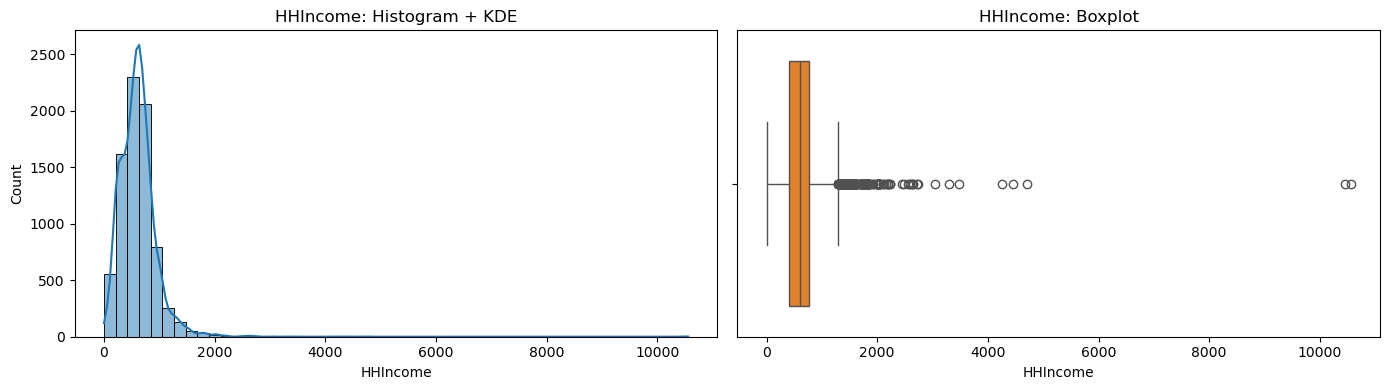

In [21]:
# Plot distribution of HHIncome (histogram + KDE and boxplot)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure data is loaded
if 'df_bilejerskab' not in globals():
    df_bilejerskab = pd.read_excel('bilejerskab2026.xlsx')

hh = df_bilejerskab['HHIncome'].dropna()
if hh.empty:
    print('HHIncome column is empty or missing')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(hh, bins=50, kde=True, ax=axes[0], color='C0')
    axes[0].set_title('HHIncome: Histogram + KDE')
    axes[0].set_xlabel('HHIncome')
    axes[0].set_ylabel('Count')

    sns.boxplot(x=hh, ax=axes[1], color='C1')
    axes[1].set_title('HHIncome: Boxplot')
    axes[1].set_xlabel('HHIncome')

    plt.tight_layout()
    plt.show()

## d) Estimate a logistic regression modelling whether a car family has 1 or 2+ cars. 
Comment on the estimated parameters and argue why your choice of final model is the most suitable.

Undersøger fordelingen af variable da der er nogle lidt mærkelige tal i modellen

For aldersgrupper

Man kan se at der er nogle grupper med meget få observationer

In [23]:
# Create new age groups: 8-18, 19-29, 30-54, 55-64, 65-84
# These will be used for a robustness check of model d)

# Ensure df_model exists
if 'df_model' not in globals():
    raise ValueError('Run c) setup first so df_model is available')

# Map original age group codes to the requested groups
new_agegroup_map = {
    2: '8_18',   # 8-14 -> 8-18
    3: '8_18',   # 15-18 -> 8-18
    4: '19_29',  # 19-24 -> 19-29
    5: '19_29',  # 25-29 -> 19-29
    6: '30_54',  # 30-54
    7: '55_64',  # 55-64
    8: '65_84',  # 65-74 -> 65-84
    9: '65_84'   # 75-84 -> 65-84
}

# Drop any existing AgeGroup_New / AgeG_New_* to avoid duplicates from prior runs
cols_to_drop = [c for c in df_model.columns if c.startswith('AgeG_New_')]
if 'AgeGroup_New' in df_model.columns:
    cols_to_drop.append('AgeGroup_New')
if cols_to_drop:
    df_model = df_model.drop(columns=cols_to_drop)

# Create new age group label column and dummies
df_model['AgeGroup_New'] = df_model['AgeGroup'].map(new_agegroup_map)
agegroup_dummies_new = pd.get_dummies(df_model['AgeGroup_New'], prefix='AgeG_New')
df_model = pd.concat([df_model, agegroup_dummies_new], axis=1)

# Show the new age group distribution in full dataset
print('=' * 80)
print('NEW AGE GROUP DISTRIBUTION (8-18, 19-29, 30-54, 55-64, 65-84)')
print('=' * 80)
new_age_dist = df_model['AgeGroup_New'].value_counts().reindex(['8_18', '19_29', '30_54', '55_64', '65_84']).fillna(0).astype(int)
print(new_age_dist)
print(f"\nTotal: {new_age_dist.sum()}")

# Display sample to verify the mapping
print('\n' + '=' * 80)
print('Sample of original -> new age groups:')
print('=' * 80)
display(df_model[['AgeGroup', 'AgeGroup_New']].drop_duplicates().sort_values('AgeGroup'))

# Get list of new age group dummy columns
age_cols_new = sorted([col for col in df_model.columns if col.startswith('AgeG_New_')])
print(f"\nNew age group dummy columns: {age_cols_new}")

# Prepare a list excluding the 30-54 new dummy for use as reference in formulas
age_cols_new_for_model = [col for col in age_cols_new if col != 'AgeG_New_30_54']
print(f"Age group dummies (reference AgeG_New_30_54 excluded): {age_cols_new_for_model}")

# If df_model_d exists (filtered 1+ car households), update it so the new dummies are present there too
if 'df_model_d' in globals():
    df_model_d = df_model[df_model['Car'] >= 1].copy()
    df_model_d['TwoPlusCars'] = (df_model_d['Car'] >= 2).astype(int)
    print('\nUpdated df_model_d (1+ car households) and AgeGroup_New distribution in this subset:')
    display(df_model_d['AgeGroup_New'].value_counts().reindex(['8_18','19_29','30_54','55_64','65_84']).fillna(0).astype(int))

NEW AGE GROUP DISTRIBUTION (8-18, 19-29, 30-54, 55-64, 65-84)
AgeGroup_New
8_18       52
19_29     738
30_54    4372
55_64    1588
65_84    1103
Name: count, dtype: int64

Total: 7853

Sample of original -> new age groups:


,AgeGroup,AgeGroup_New
130,2,8_18
58,3,8_18
24,4,19_29
7,5,19_29
1,6,30_54
0,7,55_64
5,8,65_84
28,9,65_84



New age group dummy columns: ['AgeG_New_19_29', 'AgeG_New_30_54', 'AgeG_New_55_64', 'AgeG_New_65_84', 'AgeG_New_8_18']
Age group dummies (reference AgeG_New_30_54 excluded): ['AgeG_New_19_29', 'AgeG_New_55_64', 'AgeG_New_65_84', 'AgeG_New_8_18']


For HHLicenses

In [24]:
# Cross-tabulation of HHLicenses vs TwoPlusCars in model d) dataset
# Shows why HHLicenses has separation issues in the filtered subset

if 'df_model_d' not in globals():
    raise ValueError("Run model d) first to create df_model_d")

# Create cross-tabulation: row = HHLicenses, columns = TwoPlusCars outcome
crosstab_licenses = pd.crosstab(
    df_model_d['HHLicenses'],
    df_model_d['TwoPlusCars'],
    margins=True
)

# Add percentages within each license group
crosstab_pct = pd.crosstab(
    df_model_d['HHLicenses'],
    df_model_d['TwoPlusCars'],
    normalize='index'
).round(3) * 100

print("=" * 80)
print("CROSS-TABULATION: HHLicenses vs TwoPlusCars in MODEL D) DATASET")
print("=" * 80)
print("\nAbsolute counts (margins show row and column totals):")
display(crosstab_licenses)

print("\nPercentage within each license group:")
display(crosstab_pct)

print("\n" + "=" * 80)
print("INTERPRETATION FOR SEPARATION ISSUE:")
print("=" * 80)
print("If any license group shows extreme skew (e.g., 90%+ in one outcome),")
print("that explains why the coefficient becomes unstable: the optimizer tries")
print("to push it toward infinity/negative infinity to perfectly separate the groups.")


ValueError: Run model d) first to create df_model_d

In [25]:
# Cross-tabulation: Age groups vs number of cars (0, 1, 2)
# Shows relationship between household head age and car ownership

if 'df_bilejerskab' not in globals():
    import pandas as pd
    df_bilejerskab = pd.read_excel('bilejerskab2026.xlsx')

# Ensure AgeGroupLabel exists
if 'AgeGroupLabel' not in df_bilejerskab.columns:
    agegroup_map = {
        2: '8-14',
        3: '15-18',
        4: '19-24',
        5: '25-29',
        6: '30-54',
        7: '55-64',
        8: '65-74',
        9: '75-84'
    }
    df_bilejerskab['AgeGroupLabel'] = df_bilejerskab['AgeGroup'].map(agegroup_map)

# Filter to only cars 0, 1, 2
df_cars_0_1_2 = df_bilejerskab[df_bilejerskab['Car'].isin([0, 1, 2])]

# Cross-tabulation with absolute counts and row percentages
crosstab_age_cars_count = pd.crosstab(
    df_cars_0_1_2['AgeGroupLabel'],
    df_cars_0_1_2['Car'],
    margins=True
)

crosstab_age_cars_pct = pd.crosstab(
    df_cars_0_1_2['AgeGroupLabel'],
    df_cars_0_1_2['Car'],
    normalize='index'
).round(3) * 100

# Define age group order for better readability
age_order = ['8-14', '15-18', '19-24', '25-29', '30-54', '55-64', '65-74', '75-84']

# Reindex to show in correct order (and add back the All row)
crosstab_age_cars_count = crosstab_age_cars_count.reindex(age_order + ['All']).fillna(0).astype(int)
crosstab_age_cars_pct = crosstab_age_cars_pct.reindex(age_order).fillna(0).round(1)

print("=" * 80)
print("CROSS-TABULATION: AGE GROUPS vs NUMBER OF CARS (0, 1, 2)")
print("=" * 80)

print("\nAbsolute counts (row totals):")
display(crosstab_age_cars_count)

print("\nRow percentages (%):")
display(crosstab_age_cars_pct)

print("\nInterpretation:")
print("- Rows show age groups of household heads")
print("- Columns show number of cars (0, 1, 2)")
print("- Each row sums to 100% (or approximately 100%)")
print("- Shows how car ownership distribution varies across age groups")

CROSS-TABULATION: AGE GROUPS vs NUMBER OF CARS (0, 1, 2)

Absolute counts (row totals):


Car,0,1,2,All
AgeGroupLabel,,,,
8-14,1,6,0,7
15-18,5,23,17,45
19-24,133,116,32,281
25-29,106,257,94,457
30-54,221,2665,1486,4372
55-64,59,1123,406,1588
65-74,57,695,109,861
75-84,36,197,9,242
All,618,5082,2153,7853



Row percentages (%):


Car,0,1,2
AgeGroupLabel,,,
8-14,14.3,85.7,0.0
15-18,11.1,51.1,37.8
19-24,47.3,41.3,11.4
25-29,23.2,56.2,20.6
30-54,5.1,61.0,34.0
55-64,3.7,70.7,25.6
65-74,6.6,80.7,12.7
75-84,14.9,81.4,3.7



Interpretation:
- Rows show age groups of household heads
- Columns show number of cars (0, 1, 2)
- Each row sums to 100% (or approximately 100%)
- Shows how car ownership distribution varies across age groups


Modelundersøgelse:

Start basis model

In [7]:
# Original 1 vs 2 cars model with the full requested variable set
# Reference groups:
# - HHLicenses = 1
# - AgeG = 30_54
# - LMA = Fuldtid

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Reload fresh data to avoid depending on earlier notebook state
df_model = pd.read_excel('bilejerskab2026.xlsx').copy()

# Keep only households with exactly 1 or 2 cars and create the binary target
# Car2 = 1 means 2 cars, Car2 = 0 means 1 car
df_model = df_model[df_model['Car'].isin([1, 2])].copy()
df_model['Car2'] = (df_model['Car'] == 2).astype(int)

# Gender dummy: Female = 1
df_model['Female'] = (df_model['Gender'] == 2).astype(int)

# HHLicenses dummies with 1 license as reference
df_model['HHLicenses_2'] = (df_model['HHLicenses'] == 2).astype(int)
df_model['HHLicenses_3plus'] = (df_model['HHLicenses'] >= 3).astype(int)

# Age group dummies with 30_54 as reference
agegroup_map = {2: '8_14', 3: '15_18', 4: '19_24', 5: '25_29', 6: '30_54', 7: '55_64', 8: '65_74', 9: '75_84'}
df_model['AgeGroup_Label'] = df_model['AgeGroup'].map(agegroup_map)
for label in ['19_24', '25_29', '55_64', '65_74', '75_84']:
    df_model[f'AgeG_{label}'] = (df_model['AgeGroup_Label'] == label)

# LMA dummies with Fuldtid as reference
lma_map = {1: 'Fuldtid', 2: 'Deltid', 3: 'Elev_Stud', 4: 'Pens', 5: 'Arbsog', 6: 'Uden_Arb'}
df_model['LMA_Label'] = df_model['LMA'].map(lma_map)
for label in ['Arbsog', 'Deltid', 'Elev_Stud', 'Pens', 'Uden_Arb']:
    df_model[f'LMA_{label}'] = (df_model['LMA_Label'] == label)

# Build the original full model requested by the user
formula = (
    'Car2 ~ AgeG_19_24 + AgeG_25_29 + AgeG_55_64 + AgeG_65_74 + AgeG_75_84 + '
    'LMA_Arbsog + LMA_Deltid + LMA_Elev_Stud + LMA_Pens + LMA_Uden_Arb + '
    'HHIncome + Female + HHLicenses_2 + HHLicenses_3plus + Children + Year'
)

print('Formula:')
print(formula)
print('\nReference categories: HHLicenses=1, AgeG=30_54, LMA=Fuldtid')

logit_model_original = smf.logit(formula, data=df_model).fit(disp=0)
print(logit_model_original.summary())

# Optional odds ratios for easier interpretation
ci = logit_model_original.conf_int()
or_table = pd.DataFrame({
    'OR': np.exp(logit_model_original.params),
    '2.5%': np.exp(ci[0]),
    '97.5%': np.exp(ci[1])
})
display(or_table)


Formula:
Car2 ~ AgeG_19_24 + AgeG_25_29 + AgeG_55_64 + AgeG_65_74 + AgeG_75_84 + LMA_Arbsog + LMA_Deltid + LMA_Elev_Stud + LMA_Pens + LMA_Uden_Arb + HHIncome + Female + HHLicenses_2 + HHLicenses_3plus + Children + Year

Reference categories: HHLicenses=1, AgeG=30_54, LMA=Fuldtid
                           Logit Regression Results                           
Dep. Variable:                   Car2   No. Observations:                 7235
Model:                          Logit   Df Residuals:                     7218
Method:                           MLE   Df Model:                           16
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.1174
Time:                        22:39:57   Log-Likelihood:                -3887.4
converged:                       True   LL-Null:                       -4404.7
Covariance Type:            nonrobust   LLR p-value:                4.326e-210
                            coef    std err          z      P>|z|      [0.025      0.975

/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,OR,2.5%,97.5%
Intercept,0.000000,0.000000,0.000000
AgeG_19_24[T.True],0.871156,0.557319,1.361721
AgeG_25_29[T.True],0.920406,0.709593,1.193851
AgeG_55_64[T.True],0.916751,0.777835,1.080476
AgeG_65_74[T.True],1.134903,0.778434,1.654610
AgeG_75_84[T.True],0.498120,0.231159,1.073386
LMA_Arbsog[T.True],0.603634,0.339134,1.074423
LMA_Deltid[T.True],1.170377,1.003573,1.364905
LMA_Elev_Stud[T.True],0.908236,0.631564,1.306111
LMA_Pens[T.True],0.372663,0.260054,0.534033


Endelig model

In [5]:
# Logistic regression model: 1 car vs 2 cars
# Reference groups:
# - HHLicenses = 1
# - LMA = Fuldtid

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Reload fresh data to avoid depending on earlier notebook state
df_model = pd.read_excel('bilejerskab2026.xlsx').copy()

# Keep only households with exactly 1 or 2 cars and create the binary target
# Car2 = 1 means 2 cars, Car2 = 0 means 1 car
df_model = df_model[df_model['Car'].isin([1, 2])].copy()
df_model['Car2'] = (df_model['Car'] == 2).astype(int)

# Gender dummy: Female = 1
if 'Female' not in df_model.columns:
    df_model['Female'] = (df_model['Gender'] == 2).astype(int)

# HHLicenses dummies with 1 license as reference
# These are kept numeric so the coefficient names stay plain: HHLicenses_2, HHLicenses_3plus
df_model['HHLicenses_2'] = (df_model['HHLicenses'] == 2).astype(int)
df_model['HHLicenses_3plus'] = (df_model['HHLicenses'] >= 3).astype(int)

# LMA dummies with Fuldtid as reference
# Boolean dtype gives the desired patsy names like LMA_Deltid[T.True]
lma_map = {1: 'Fuldtid', 2: 'Deltid', 3: 'Elev_Stud', 4: 'Pens', 5: 'Arbsog', 6: 'Uden_Arb'}
df_model['LMA_Label'] = df_model['LMA'].map(lma_map)
for label in ['Arbsog', 'Deltid', 'Pens', 'Uden_Arb']:
    df_model[f'LMA_{label}'] = (df_model['LMA_Label'] == label)

# Baseline model
formula = (
    'Car2 ~ LMA_Arbsog + LMA_Deltid + LMA_Pens + LMA_Uden_Arb + '
    'HHIncome + Female + HHLicenses_2 + HHLicenses_3plus + Children + Year'
)

print('Formula:')
print(formula)
print('\nReference categories: HHLicenses=1, LMA=Fuldtid')

logit_model_1v2 = smf.logit(formula, data=df_model).fit(disp=0)
print(logit_model_1v2.summary())

# Compare alternative income specifications on the same model structure.
# Standardizing HHIncome improves numerical stability while keeping the model comparison valid.
hh_income_mean = df_model['HHIncome'].mean()
hh_income_std = df_model['HHIncome'].std()
df_model['HHIncome_std'] = (df_model['HHIncome'] - hh_income_mean) / hh_income_std
df_model['HHIncome_log'] = np.log1p(df_model['HHIncome'])

formula_linear = (
    'Car2 ~ LMA_Arbsog + LMA_Deltid + LMA_Pens + LMA_Uden_Arb + '
    'HHIncome_std + Female + HHLicenses_2 + HHLicenses_3plus + Children + Year'
)
formula_quadratic = (
    'Car2 ~ LMA_Arbsog + LMA_Deltid + LMA_Pens + LMA_Uden_Arb + '
    'HHIncome_std + I(HHIncome_std**2) + Female + HHLicenses_2 + HHLicenses_3plus + Children + Year'
)
formula_log = (
    'Car2 ~ LMA_Arbsog + LMA_Deltid + LMA_Pens + LMA_Uden_Arb + '
    'HHIncome_log + Female + HHLicenses_2 + HHLicenses_3plus + Children + Year'
)

model_linear = smf.logit(formula_linear, data=df_model).fit(disp=0, method='bfgs', maxiter=500)
model_quadratic = smf.logit(formula_quadratic, data=df_model).fit(disp=0, method='bfgs', maxiter=500)
model_log = smf.logit(formula_log, data=df_model).fit(disp=0, method='bfgs', maxiter=500)

comparison_table = pd.DataFrame({
    'Model': ['Linear HHIncome', 'Quadratic HHIncome', 'Log HHIncome'],
    'Pseudo R-squared': [model_linear.prsquared, model_quadratic.prsquared, model_log.prsquared],
    'AIC': [model_linear.aic, model_quadratic.aic, model_log.aic],
    'BIC': [model_linear.bic, model_quadratic.bic, model_log.bic],
    'N_obs': [model_linear.nobs, model_quadratic.nobs, model_log.nobs]
})
comparison_table['Pseudo R-squared'] = comparison_table['Pseudo R-squared'].round(4)
comparison_table['AIC'] = comparison_table['AIC'].round(2)
comparison_table['BIC'] = comparison_table['BIC'].round(2)

print('\nIncome specification comparison:')
display(comparison_table)

# Optional odds ratios for easier interpretation
ci = logit_model_1v2.conf_int()
or_table = pd.DataFrame({
    'OR': np.exp(logit_model_1v2.params),
    '2.5%': np.exp(ci[0]),
    '97.5%': np.exp(ci[1])
})
display(or_table)


Formula:
Car2 ~ LMA_Arbsog + LMA_Deltid + LMA_Pens + LMA_Uden_Arb + HHIncome + Female + HHLicenses_2 + HHLicenses_3plus + Children + Year

Reference categories: HHLicenses=1, LMA=Fuldtid
                           Logit Regression Results                           
Dep. Variable:                   Car2   No. Observations:                 7235
Model:                          Logit   Df Residuals:                     7224
Method:                           MLE   Df Model:                           10
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.1165
Time:                        22:35:48   Log-Likelihood:                -3891.6
converged:                       True   LL-Null:                       -4404.7
Covariance Type:            nonrobust   LLR p-value:                4.269e-214
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Int

/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  

,Model,Pseudo R-squared,AIC,BIC,N_obs
0,Linear HHIncome,0.1165,7805.16,7880.92,7235
1,Quadratic HHIncome,0.1219,7759.15,7841.79,7235
2,Log HHIncome,0.1159,7809.98,7885.73,7235


,OR,2.5%,97.5%
Intercept,0.000000,0.000000,0.000000
LMA_Arbsog[T.True],0.606533,0.340958,1.078966
LMA_Deltid[T.True],1.178279,1.012779,1.370823
LMA_Pens[T.True],0.393668,0.315451,0.491279
LMA_Uden_Arb[T.True],0.590642,0.443877,0.785934
HHIncome,1.000932,1.000738,1.001126
Female,0.795576,0.709076,0.892628
HHLicenses_2,7.081721,5.108094,9.817904
HHLicenses_3plus,14.034563,9.741486,20.219602
Children,1.108489,1.050802,1.169343


Undersøgelse af non-linear effects

In [8]:
# Compare the same 1-vs-2 cars model using linear, quadratic, and log income specifications
# Metrics reported: pseudo R-squared, AIC, and BIC

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Reload fresh data to avoid depending on earlier notebook state
df_model_compare = pd.read_excel('bilejerskab2026.xlsx').copy()

# Keep only households with exactly 1 or 2 cars and create the binary target
# Car2 = 1 means 2 cars, Car2 = 0 means 1 car
df_model_compare = df_model_compare[df_model_compare['Car'].isin([1, 2])].copy()
df_model_compare['Car2'] = (df_model_compare['Car'] == 2).astype(int)

# Gender dummy: Female = 1
if 'Female' not in df_model_compare.columns:
    df_model_compare['Female'] = (df_model_compare['Gender'] == 2).astype(int)

# HHLicenses dummies with 1 license as reference
df_model_compare['HHLicenses_2'] = (df_model_compare['HHLicenses'] == 2).astype(int)
df_model_compare['HHLicenses_3plus'] = (df_model_compare['HHLicenses'] >= 3).astype(int)

# LMA dummies with Fuldtid as reference
lma_map = {1: 'Fuldtid', 2: 'Deltid', 3: 'Elev_Stud', 4: 'Pens', 5: 'Arbsog', 6: 'Uden_Arb'}
df_model_compare['LMA_Label'] = df_model_compare['LMA'].map(lma_map)
for label in ['Arbsog', 'Deltid', 'Pens', 'Uden_Arb']:
    df_model_compare[f'LMA_{label}'] = (df_model_compare['LMA_Label'] == label)

# Use standardized income for the linear and quadratic specifications
hh_income_mean = df_model_compare['HHIncome'].mean()
hh_income_std = df_model_compare['HHIncome'].std()
df_model_compare['HHIncome_std'] = (df_model_compare['HHIncome'] - hh_income_mean) / hh_income_std
df_model_compare['HHIncome_log'] = np.log1p(df_model_compare['HHIncome'])

# Same model structure, only income specification changes
base_rhs = 'LMA_Arbsog + LMA_Deltid + LMA_Pens + LMA_Uden_Arb + Female + HHLicenses_2 + HHLicenses_3plus + Children + Year'

formula_linear = f'Car2 ~ HHIncome_std + {base_rhs}'
formula_quadratic = f'Car2 ~ HHIncome_std + I(HHIncome_std**2) + {base_rhs}'
formula_log = f'Car2 ~ HHIncome_log + {base_rhs}'

model_linear = smf.logit(formula_linear, data=df_model_compare).fit(disp=0, method='bfgs', maxiter=500)
model_quadratic = smf.logit(formula_quadratic, data=df_model_compare).fit(disp=0, method='bfgs', maxiter=500)
model_log = smf.logit(formula_log, data=df_model_compare).fit(disp=0, method='bfgs', maxiter=500)

comparison_table = pd.DataFrame({
    'Model': ['Linear HHIncome', 'Quadratic HHIncome', 'Log HHIncome'],
    'Pseudo R-squared': [model_linear.prsquared, model_quadratic.prsquared, model_log.prsquared],
    'AIC': [model_linear.aic, model_quadratic.aic, model_log.aic],
    'BIC': [model_linear.bic, model_quadratic.bic, model_log.bic],
    'N_obs': [model_linear.nobs, model_quadratic.nobs, model_log.nobs]
})
comparison_table['Pseudo R-squared'] = comparison_table['Pseudo R-squared'].round(4)
comparison_table['AIC'] = comparison_table['AIC'].round(2)
comparison_table['BIC'] = comparison_table['BIC'].round(2)

print('Income specification comparison:')
display(comparison_table)

print("\n" + "="*80)
print("MODEL 1: LINEAR HHIncome_std")
print("="*80)
print(model_linear.summary())

print("\n" + "="*80)
print("MODEL 2: QUADRATIC HHIncome_std + I(HHIncome_std**2)")
print("="*80)
print(model_quadratic.summary())

print("\n" + "="*80)
print("MODEL 3: LOG HHIncome_log")
print("="*80)
print(model_log.summary())

Income specification comparison:


/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  

,Model,Pseudo R-squared,AIC,BIC,N_obs
0,Linear HHIncome,0.1165,7805.16,7880.92,7235
1,Quadratic HHIncome,0.1219,7759.15,7841.79,7235
2,Log HHIncome,0.1159,7809.98,7885.73,7235



MODEL 1: LINEAR HHIncome_std
                           Logit Regression Results                           
Dep. Variable:                   Car2   No. Observations:                 7235
Model:                          Logit   Df Residuals:                     7224
Method:                           MLE   Df Model:                           10
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.1165
Time:                        22:47:59   Log-Likelihood:                -3891.6
converged:                       True   LL-Null:                       -4404.7
Covariance Type:            nonrobust   LLR p-value:                4.269e-214
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -1239.6184    113.099    -10.960      0.000   -1461.289   -1017.948
LMA_Arbsog[T.True]      -0.5000      0.294     -1.701      0.089      -

## e) Effect of a 20% income increase

Below I use the final logistic models from c) and d) to estimate how a 20% increase in household income changes the predicted probability of having a car, having 2+ cars, and the expected number of cars. The idea is to keep all other observed characteristics fixed and compare the baseline prediction with a counterfactual where `HHIncome` is multiplied by `1.2`.

In [10]:
# e) Counterfactual analysis: 20% higher income
# Self-contained version: rebuilds the needed c) and d) models if they are not already in memory.

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Load the raw data
if 'df_bilejerskab' in globals():
    df_eval = df_bilejerskab.copy()
else:
    df_eval = pd.read_excel('bilejerskab2026.xlsx')

# Build the dummies needed by the final models
if 'Female' not in df_eval.columns:
    df_eval['Female'] = (df_eval['Gender'] == 2).astype(int)

agegroup_map = {2: '8_14', 3: '15_18', 4: '19_24', 5: '25_29', 6: '30_54', 7: '55_64', 8: '65_74', 9: '75_84'}
if 'AgeGroup_Label' not in df_eval.columns:
    df_eval['AgeGroup_Label'] = df_eval['AgeGroup'].map(agegroup_map)
required_age_cols = ['AgeG_19_24', 'AgeG_25_29', 'AgeG_55_64', 'AgeG_65_74', 'AgeG_75_84']
if any(col not in df_eval.columns for col in required_age_cols):
    df_eval = pd.concat([df_eval, pd.get_dummies(df_eval['AgeGroup_Label'], prefix='AgeG')], axis=1)

lma_map = {1: 'Fuldtid', 2: 'Deltid', 3: 'Elev_Stud', 4: 'Pens', 5: 'Arbsog', 6: 'Uden_Arb'}
if 'LMA_Label' not in df_eval.columns:
    df_eval['LMA_Label'] = df_eval['LMA'].map(lma_map)
required_lma_cols = ['LMA_Elev_Stud', 'LMA_Deltid', 'LMA_Pens', 'LMA_Uden_Arb']
if any(col not in df_eval.columns for col in required_lma_cols):
    df_eval = pd.concat([df_eval, pd.get_dummies(df_eval['LMA_Label'], prefix='LMA')], axis=1)

# License dummies for both model versions
if 'HHLicenses_1' not in df_eval.columns:
    df_eval['HHLicenses_1'] = (df_eval['HHLicenses'] == 1).astype(int)
if 'HHLicenses_2plus' not in df_eval.columns:
    df_eval['HHLicenses_2plus'] = df_eval['HHLicenses'].isin([2, 3, 4, 5]).astype(int)
if 'HHLicenses_2' not in df_eval.columns:
    df_eval['HHLicenses_2'] = (df_eval['HHLicenses'] == 2).astype(int)
if 'HHLicenses_3plus' not in df_eval.columns:
    df_eval['HHLicenses_3plus'] = (df_eval['HHLicenses'] >= 3).astype(int)

# Final c) model used for the comparison
age_c = ['AgeG_19_24', 'AgeG_25_29', 'AgeG_55_64', 'AgeG_65_74', 'AgeG_75_84']
lma_c = ['LMA_Elev_Stud']
formula_c = 'HaveCar ~ HHIncome + HHLicenses_1 + HHLicenses_2plus + Children + ' + ' + '.join(age_c + lma_c)

# Final d) model used for the comparison
# Use the quadratic 2+ cars model we just built, while keeping the earlier HaveCar model unchanged
hh_income_mean = df_eval['HHIncome'].mean()
hh_income_std = df_eval['HHIncome'].std()
df_eval['HHIncome_std'] = (df_eval['HHIncome'] - hh_income_mean) / hh_income_std
formula_d_quad = 'TwoPlusCars ~ HHIncome_std + I(HHIncome_std**2) + Female + HHLicenses_2 + HHLicenses_3plus + Children + LMA_Deltid + LMA_Pens + LMA_Uden_Arb'

# Create target variables
c_data = df_eval.copy()
c_data['HaveCar'] = c_data['Car'].isin([1, 2]).astype(int)
d_data = df_eval[df_eval['Car'] >= 1].copy()
d_data['TwoPlusCars'] = (d_data['Car'] >= 2).astype(int)
d_data['HHIncome_std'] = (d_data['HHIncome'] - hh_income_mean) / hh_income_std

# Fit models if they are not already available in memory
model_c = globals().get('logit_model_reduced')
if model_c is None:
    model_c = smf.logit(formula_c, data=c_data).fit(disp=0)

model_d = globals().get('model_d_quad')
if model_d is None:
    model_d = smf.logit(formula_d_quad, data=d_data).fit(disp=0, method='bfgs', maxiter=500)
model_d_quad = model_d

# Counterfactual income shock
# Everyone gets 20% higher HHIncome, all other observed characteristics remain fixed.
df_shock = df_eval.copy()
df_shock['HHIncome'] = df_shock['HHIncome'] * 1.2
df_shock['HHIncome_std'] = (df_shock['HHIncome'] - hh_income_mean) / hh_income_std

print('=' * 100)
print('E) COUNTERFACTUAL ANALYSIS: 20% HIGHER INCOME')
print('=' * 100)
print('Approach:')
print('1. Use the final c) model for P(have car).')
print('2. Use the final d) model for P(2+ cars | have car).')
print('3. Recompute both probabilities after multiplying HHIncome by 1.2.')
print('4. Combine them to get an expected number of cars per household.')

# Baseline predictions
p_have_base = pd.Series(model_c.predict(c_data), index=c_data.index, name='p_have_base')
p_two_plus_base = pd.Series(model_d.predict(df_eval), index=df_eval.index, name='p_two_plus_base')
expected_cars_base = p_have_base * (1 + p_two_plus_base)

# Counterfactual predictions with +20% income
c_shock_data = c_data.copy()
c_shock_data['HHIncome'] = c_shock_data['HHIncome'] * 1.2
p_have_shock = pd.Series(model_c.predict(c_shock_data), index=c_shock_data.index, name='p_have_shock')
p_two_plus_shock = pd.Series(model_d.predict(df_shock), index=df_shock.index, name='p_two_plus_shock')
expected_cars_shock = p_have_shock * (1 + p_two_plus_shock)

# Summary table
results = pd.DataFrame({
    'Metric': [
        'P(have car)',
        'P(2+ cars | have car)',
        'Expected cars per household',
        'Expected total cars in sample'
    ],
    'Baseline': [
        p_have_base.mean(),
        p_two_plus_base.mean(),
        expected_cars_base.mean(),
        expected_cars_base.sum()
    ],
    '20% higher income': [
        p_have_shock.mean(),
        p_two_plus_shock.mean(),
        expected_cars_shock.mean(),
        expected_cars_shock.sum()
    ]
})
results['Change'] = results['20% higher income'] - results['Baseline']
results['Change_pct'] = np.where(results['Baseline'] != 0, (results['Change'] / results['Baseline']) * 100, np.nan)

results['Baseline'] = results['Baseline'].round(4)
results['20% higher income'] = results['20% higher income'].round(4)
results['Change'] = results['Change'].round(4)
results['Change_pct'] = results['Change_pct'].round(2)

print('\nModel comparison table:')
display(results)

print('\nInterpretation helper:')
print('- The first two rows show the extensive and intensive margins separately.')
print('- The third row is the main answer: expected number of cars per household.')
print('- The fourth row converts that to the expected total number of cars in the sample.')

print(f"\nSample size used for prediction: {len(df_eval)}")

E) COUNTERFACTUAL ANALYSIS: 20% HIGHER INCOME
Approach:
1. Use the final c) model for P(have car).
2. Use the final d) model for P(2+ cars | have car).
3. Recompute both probabilities after multiplying HHIncome by 1.2.
4. Combine them to get an expected number of cars per household.

Model comparison table:


/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,Metric,Baseline,20% higher income,Change,Change_pct
0,P(have car),0.9213,0.9270,0.0057,0.62
1,P(2+ cars | have car),0.2835,0.3146,0.0311,10.96
2,Expected cars per household,1.1951,1.2322,0.0372,3.11
3,Expected total cars in sample,9384.8033,9676.8021,291.9988,3.11



Interpretation helper:
- The first two rows show the extensive and intensive margins separately.
- The third row is the main answer: expected number of cars per household.
- The fourth row converts that to the expected total number of cars in the sample.

Sample size used for prediction: 7853


### How to read the result

The first model gives the probability of having at least one car, while the second model is conditional on already having at least one car and gives the probability of moving from 1 car to 2+ cars. Combining them gives an expected number of cars per household. This is the cleanest way to answer the question with the models already built in c) and d), because it separates the extensive margin (car ownership at all) from the intensive margin (one car versus more than one).

>e) Apply the model(s) from c) and d) that you find necessary to assess how a 20 % increase in
income affects the demand for cars, i.e. the probability of car or 2+ cars in one or both of you
models. Alternatively, you are welcome to set up a logit model (or multinomial logistic
regression) to answer this question instead. Apply your preferred approach to predict how
many cars the sample is ex